## World Terror Incident Visualizations, December 2009-October 2010
### Using pandas, matplotlib, and seaborn

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [152]:
conda env list


# conda environments:
#
                       /Users/blauerbock/.ai-navigator/micromamba/envs/metal
base                   /opt/anaconda3
HuggingFaceBook        /opt/anaconda3/envs/HuggingFaceBook
content-compare        /opt/anaconda3/envs/content-compare
islp                   /opt/anaconda3/envs/islp
langsmith              /opt/anaconda3/envs/langsmith
llm-from-scratch       /opt/anaconda3/envs/llm-from-scratch
llms                   /opt/anaconda3/envs/llms
py313                * /opt/anaconda3/envs/py313
python-ds-ml-bootcamp   /opt/anaconda3/envs/python-ds-ml-bootcamp


Note: you may need to restart the kernel to use updated packages.


In [153]:
df = pd.read_csv('data/world_terror_incidents.csv')
df.shape

(8979, 26)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8979 entries, 0 to 8978
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ICN                        8979 non-null   int64 
 1   Incident_Date              8979 non-null   object
 2   Date_Stamp                 8979 non-null   object
 3   Subject                    8979 non-null   object
 4   Country                    8979 non-null   object
 5   ISO-3166-2                 8979 non-null   object
 6   City                       8615 non-null   object
 7   Geocode                    8979 non-null   object
 8   Geocode_Anchor             8979 non-null   object
 9   Incident_Group_Type        8979 non-null   object
 10  Summary                    8979 non-null   object
 11  Related_Term               8979 non-null   object
 12  Incident_Victims_Dead      8979 non-null   int64 
 13  Incident_Victims_Hostaged  8979 non-null   int64 
 14  Incident

In [155]:
df['Date'] = df['Date_Stamp'].apply(lambda x: pd.to_datetime(x))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8979 entries, 0 to 8978
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ICN                        8979 non-null   int64         
 1   Incident_Date              8979 non-null   object        
 2   Date_Stamp                 8979 non-null   object        
 3   Subject                    8979 non-null   object        
 4   Country                    8979 non-null   object        
 5   ISO-3166-2                 8979 non-null   object        
 6   City                       8615 non-null   object        
 7   Geocode                    8979 non-null   object        
 8   Geocode_Anchor             8979 non-null   object        
 9   Incident_Group_Type        8979 non-null   object        
 10  Summary                    8979 non-null   object        
 11  Related_Term               8979 non-null   object        
 12  Incide

In [156]:
# df = pd.DataFrame(technologies)
col = df.pop("Date")
print(col)
df.shape

0      2010-07-01
1      2010-09-26
2      2010-09-10
3      2010-02-14
4      2010-07-28
          ...    
8974   2010-09-29
8975   2010-01-01
8976   2010-09-13
8977   2010-02-22
8978   2010-07-28
Name: Date, Length: 8979, dtype: datetime64[ns]


(8979, 26)

In [157]:
col.name

'Date'

In [158]:
df.insert(1, col.name, col)

In [160]:
df.to_csv('data/world_terror_incidents_250818.csv')
df.head(2)

,ICN,Date,Incident_Date,Date_Stamp,Subject,Country,ISO-3166-2,City,Geocode,Geocode_Anchor,Incident_Group_Type,Summary,Related_Term,Incident_Victims_Dead,Incident_Victims_Hostaged,Incident_Victims_Wounded,Incident_Included_Victims,Weapon,Event_Type,Geocode_Has_Value,Province_State,Assassination,IED,Incident_Day,Incident_Month,Month_Number,Incident_Year
0,201011951,2010-07-01,1-Jul-10,2010-07-01,"1 bridge damaged in IED attack in Herat, Herat...",Afghanistan,AF,Herat,"34.363201,62.184971","Herat, Herat, Afghanistan,",Islamic Extremist (Sunni),"On 1 July 2010, in Herat, Herat, Afghanistan, ...","Afghanistan, bridge, Herat, July, targeting",0,0,0,No,"Explosive, IED",Bombing,Yes,Herat,No,Yes,1,Jul,7,2010
1,201014823,2010-09-26,26-Sep-10,2010-09-26,"2 civilians killed in armed attack in Lowgar, ...",Afghanistan,AF,Lowgar,"34.019299,69.021111","Lowgar, Afghanistan,",Islamic Extremist (Sunni),"On 26 September 2010, in Lowgar, Afghanistan, ...","Afghanistan, Lowgar, September",2,0,0,Yes,Firearm,Armed Attack,Yes,Lowgar,No,No,26,Sep,9,2010


In [140]:
df.shape

(8979, 27)

In [141]:
pd.set_option('display.max_columns', len(df.columns))  # display all the columns
df.head(5)

,ICN,Date,Incident_Date,Date_Stamp,Subject,Country,ISO-3166-2,City,Geocode,Geocode_Anchor,Incident_Group_Type,Summary,Related_Term,Incident_Victims_Dead,Incident_Victims_Hostaged,Incident_Victims_Wounded,Incident_Included_Victims,Weapon,Event_Type,Geocode_Has_Value,Province_State,Assassination,IED,Incident_Day,Incident_Month,Month_Number,Incident_Year
0,201011951,2010-07-01,1-Jul-10,2010-07-01,"1 bridge damaged in IED attack in Herat, Herat...",Afghanistan,AF,Herat,"34.363201,62.184971","Herat, Herat, Afghanistan,",Islamic Extremist (Sunni),"On 1 July 2010, in Herat, Herat, Afghanistan, ...","Afghanistan, bridge, Herat, July, targeting",0,0,0,No,"Explosive, IED",Bombing,Yes,Herat,No,Yes,1,Jul,7,2010
1,201014823,2010-09-26,26-Sep-10,2010-09-26,"2 civilians killed in armed attack in Lowgar, ...",Afghanistan,AF,Lowgar,"34.019299,69.021111","Lowgar, Afghanistan,",Islamic Extremist (Sunni),"On 26 September 2010, in Lowgar, Afghanistan, ...","Afghanistan, Lowgar, September",2,0,0,Yes,Firearm,Armed Attack,Yes,Lowgar,No,No,26,Sep,9,2010
2,201013905,2010-09-10,10-Sep-10,2010-09-10,3 political party workers kidnapped in Baraki ...,Afghanistan,AF,Baraki Barak,"33.967499,68.948608","Baraki Barak, Lowgar, Afghanistan,",Islamic Extremist (Sunni),"On 10 September 2010, in Baraki Barak, Lowgar,...","Baraki Barak, candidate, Lowgar, parliamentary...",0,3,0,Yes,Firearm,Kidnapping,Yes,Lowgar,No,No,10,Sep,9,2010
3,201006361,2010-02-14,14-Feb-10,2010-02-14,"2 police officers killed, 2 others wounded in ...",Afghanistan,AF,Dwahmande,"33.281666,69.584999","Dwahmande, Khowst, Afghanistan,",Islamic Extremist (Sunni),"On 14 February 2010, in Dwahmande, Khowst, Afg...","Dwahmande, February, Khowst, police, police ve...",2,0,2,Yes,"Explosive, IED",Bombing,Yes,Khowst,No,Yes,14,Feb,2,2010
4,201012487,2010-07-28,28-Jul-10,2010-07-28,"1 teacher killed in armed attack in Kaldar, Ba...",Afghanistan,AF,Kaldar,"37.166668,67.774170","Kaldar, Balkh, Afghanistan,",Islamic Extremist (Sunni),"Before 28 July 2010, in Kaldar, Balkh, Afghani...","Balkh, home, Kaldar, teacher",1,0,0,Yes,Firearm,Armed Attack,Yes,Balkh,No,No,28,Jul,7,2010


In [30]:
df['Weapon'].str.count(',').value_counts()

Weapon
0    5351
1    3447
2     152
3      24
4       3
5       1
6       1
Name: count, dtype: int64

In [31]:
df[df['Event_Type'].str.count(',')>0].head()

,ICN,Incident_Date,Date_Stamp,Subject,Country,ISO-3166-2,City,Geocode,Geocode_Anchor,Incident_Group_Type,Summary,Related_Term,Incident_Victims_Dead,Incident_Victims_Hostaged,Incident_Victims_Wounded,Incident_Included_Victims,Weapon,Event_Type,Geocode_Has_Value,Province_State,Assassination,IED,Incident_Day,Incident_Month,Month_Number,Incident_Year
20,201012189,5-Aug-10,2010-08-05,10 NGO workers held hostage and killed in arme...,Afghanistan,AF,NaN,"36.750000,72.000000","Badakhshan, Afghanistan,",Islamic Extremist (Sunni),"On 5 August 2010, at about 7:30 AM, in Badakhs...","Afghan, aid workers, belongings, Briton, Hizb,...",10,1,0,Yes,"Firearm, Grenade","Armed Attack, Barricade/Hostage, Theft",Yes,Badakhshan,No,No,5,Aug,8,2010
40,201011638,4-Jul-10,2010-07-04,6 civilians kidnapped and killed by suspected ...,Afghanistan,AF,Andar,"33.125279,67.982498","Andar, Ghazni, Afghanistan,",Islamic Extremist (Sunni),"On 4 July 2010, in Andar, Ghazni, Afghanistan,...","Andar, construction, construction workers, Gha...",6,0,0,Yes,Unknown,"Kidnapping, Unknown",Yes,Ghazni,No,No,4,Jul,7,2010
44,201005724,4-Feb-10,2010-02-04,"5 civilians, 1 child killed, 20 civilians woun...",Afghanistan,AF,Kandahar,"31.612499,65.709442","Kandahar, Kandahar, Afghanistan,",Islamic Extremist (Sunni),"On 4 February 2010, at about 7:30 PM, in Kanda...","hotel, Kandahar, security forces, targeting se...",6,0,20,Yes,"Explosive, IED","Bombing, Suicide",Yes,Kandahar,No,Yes,4,Feb,2,2010
45,201010111,1-Jun-10,2010-06-01,2 vehicles stolen by suspected Taliban in Pol-...,Afghanistan,AF,Pol-e Khomri,"35.934429,68.771233","Pol-e H?umr?, Baghlan, Afghanistan,",Islamic Extremist (Sunni),"On 1 June 2010, in Pol-e Khomri, Baghlan, Afgh...","Baghlan, means, oil tanker, tanker, truck, unk...",0,0,0,Yes,Unknown,"Theft, Unknown",Yes,Baghlan,No,No,1,Jun,6,2010
48,201013022,18-Aug-10,2010-08-18,"1 child killed, 1 civilian, 1 political candid...",Afghanistan,AF,Alingar,"34.834721,70.359169","`Alingar, Laghman, Afghanistan,",Islamic Extremist (Sunni),"On 18 August 2010, in the evening, in Alingar,...","Alingar, candidate, Laghman, money, nephew, pa...",1,0,2,Yes,"Firearm, Primitive","Armed Attack, Assault, Theft",Yes,Laghman,No,No,18,Aug,8,2010


In [32]:
df['Event_Type'].str.len().sort_values()

2345     5
1627     5
3452     5
1575     5
1747     5
        ..
1600    61
1338    61
1771    61
1167    68
6497    80
Name: Event_Type, Length: 8979, dtype: int64

In [48]:
df['Event_Type_List'] = df['Event_Type'].apply(lambda my_string: [x.strip() for x in my_string.split(',')])

In [21]:
df['Summary'].str.len().sort_values(ascending=False)

913     1206
8843    1008
4684     950
6497     901
4121     831
        ... 
2200     116
378      116
1304     116
721      115
5253     113
Name: Summary, Length: 8979, dtype: int64

In [73]:
from sklearn.preprocessing import MultiLabelBinarizer
# df = pd.DataFrame({"genre": [["action", "drama","fantasy"], ["fantasy","action"], ["drama"], ["sci-fi", "drama"]]})
# print(df)
mlb = MultiLabelBinarizer()
event_type_df = pd.DataFrame(mlb.fit_transform(df['Event_Type_List']),columns=mlb.classes_)
event_type_df.to_csv('event_type.csv')
#df2.columns
#df2.sum(axis=0)
event_type_df.head()

,Armed Attack,Arson/Firebombing,Assassination,Assault,Barricade/Hostage,Bombing,Hijacking,Hoax,Kidnapping,Near Miss/Non Attack Incident,Other,Suicide,Theft,Threat,Unknown,Vandalism
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [85]:
# event_type_corr_matrix = event_type_df.corr()

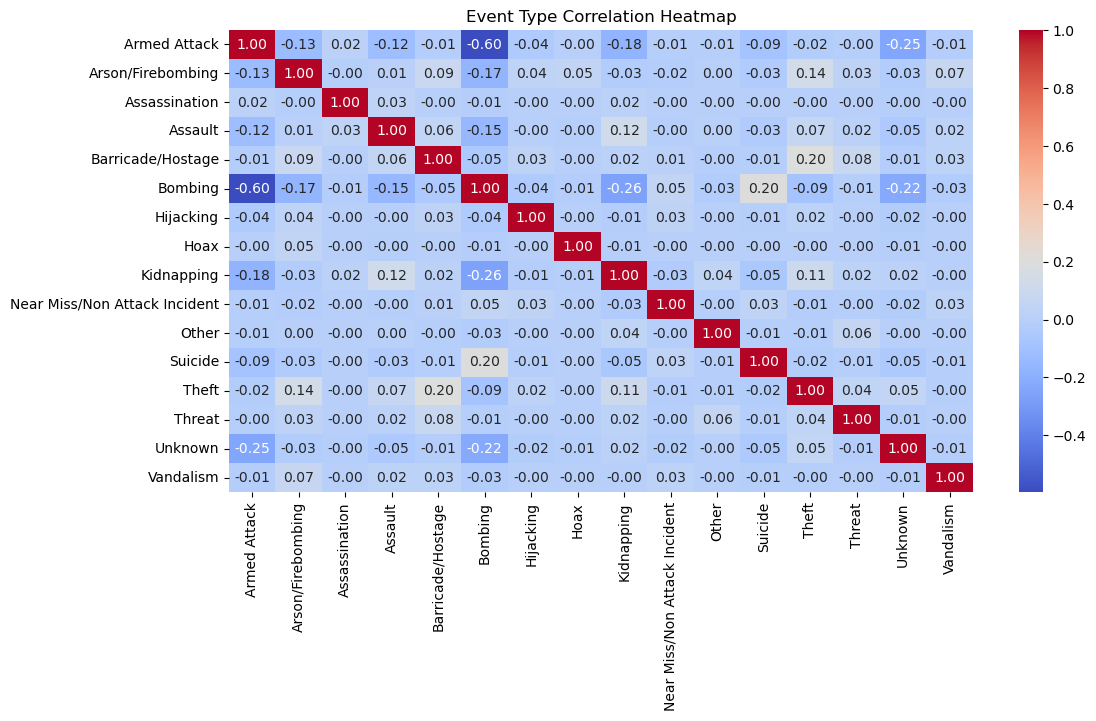

In [84]:
event_type_corr_matrix = event_type_df.corr()
plt.figure(figsize=(12, 6)) # Adjust figure size as needed
sns.heatmap(event_type_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Event Type Correlation Heatmap')
plt.show()

In [72]:
df['Weapon_List'] = df['Weapon'].apply(lambda my_string: [x.strip() for x in my_string.split(',')])
weapon_df = pd.DataFrame(mlb.fit_transform(df['Weapon_List']),columns=mlb.classes_)
weapon_df.to_csv('weapons.csv')
#df2.columns
#df2.sum(axis=0)
weapon_df.head()

,Explosive,Fake device,Firearm,Firebomb/Incendiary,Grenade,IED,Landmine,Letter Bomb,Missile/Rocket,Mortar/Artillery,Other,Primitive,RPG,Toxic,Unknown,Vehicle bomb
0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


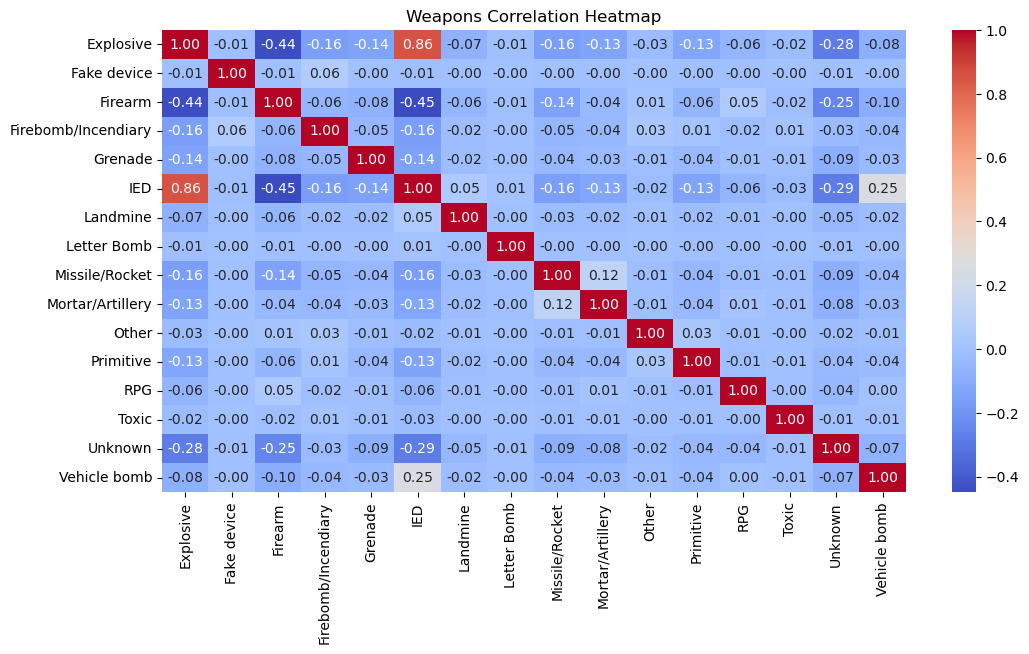

In [87]:
weapon_corr_matrix = weapon_df.corr()
plt.figure(figsize=(12, 6)) # Adjust figure size as needed
sns.heatmap(weapon_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Weapons Correlation Heatmap')
plt.show()

In [64]:
print(weapon_df.shape)
display(weapon_df.sum().sort_values(ascending=False))
weapon_df.sum().sort_values(ascending=False).sum()

(8979, 16)


IED                    3051
Explosive              2996
Firearm                2939
Unknown                1272
Firebomb/Incendiary     493
Missile/Rocket          446
Grenade                 431
Primitive               333
Mortar/Artillery        332
Vehicle bomb            280
Landmine                109
RPG                      95
Other                    33
Toxic                    11
Fake device               2
Letter Bomb               2
dtype: int64

12825

In [71]:
# weapon_df.sum(axis=1).value_counts()
weapon_df[weapon_df.sum(axis=1) > 6]

,Explosive,Fake device,Firearm,Firebomb/Incendiary,Grenade,IED,Landmine,Letter Bomb,Missile/Rocket,Mortar/Artillery,Other,Primitive,RPG,Toxic,Unknown,Vehicle bomb
913,1,0,1,0,1,1,0,0,1,1,0,0,0,0,0,1


In [63]:
print(event_type_df.shape)
event_type_df.sum().sort_values(ascending=False)

(8979, 16)


Armed Attack                     3718
Bombing                          3341
Kidnapping                        965
Unknown                           707
Arson/Firebombing                 492
Assault                           361
Suicide                           213
Theft                             134
Near Miss/Non Attack Incident      94
Barricade/Hostage                  92
Hijacking                          31
Other                              17
Threat                             14
Vandalism                          12
Hoax                                3
Assassination                       2
dtype: int64

<Axes: >

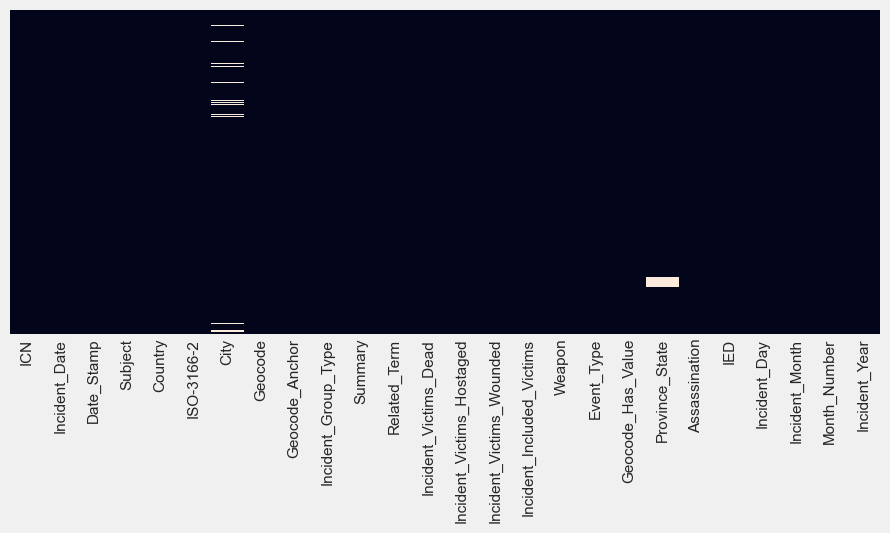

In [184]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

In [99]:
numeric_df = df.select_dtypes(include='int64').drop('ICN', axis=1)

In [100]:
corr_matrix = numeric_df.corr(numeric_only=True)

In [101]:
corr_matrix

,Incident_Victims_Dead,Incident_Victims_Hostaged,Incident_Victims_Wounded,Incident_Day,Month_Number,Incident_Year
Incident_Victims_Dead,1.000000,0.023838,0.693486,0.007383,-0.009829,-0.020614
Incident_Victims_Hostaged,0.023838,1.000000,0.066800,-0.000039,-0.008394,-0.006201
Incident_Victims_Wounded,0.693486,0.066800,1.000000,0.006510,-0.002376,-0.014378
Incident_Day,0.007383,-0.000039,0.006510,1.000000,-0.014654,-0.216535
Month_Number,-0.009829,-0.008394,-0.002376,-0.014654,1.000000,-0.072408
Incident_Year,-0.020614,-0.006201,-0.014378,-0.216535,-0.072408,1.000000


In [102]:
df.describe()

,ICN,Incident_Victims_Dead,Incident_Victims_Hostaged,Incident_Victims_Wounded,Incident_Day,Month_Number,Incident_Year
count,8.979000e+03,8979.000000,8979.000000,8979.000000,8979.000000,8979.000000,8979.000000
mean,2.010057e+08,1.162379,0.504065,2.771244,16.112262,5.697516,2009.958459
std,1.990298e+04,4.371189,3.688902,12.513028,8.664143,2.766080,0.199550
min,2.009113e+08,0.000000,0.000000,0.000000,1.000000,1.000000,2009.000000
25%,2.010071e+08,0.000000,0.000000,0.000000,8.000000,3.000000,2010.000000
50%,2.010100e+08,0.000000,0.000000,0.000000,17.000000,6.000000,2010.000000
75%,2.010127e+08,1.000000,0.000000,2.000000,23.000000,8.000000,2010.000000
max,2.010172e+08,148.000000,116.000000,318.000000,31.000000,12.000000,2010.000000


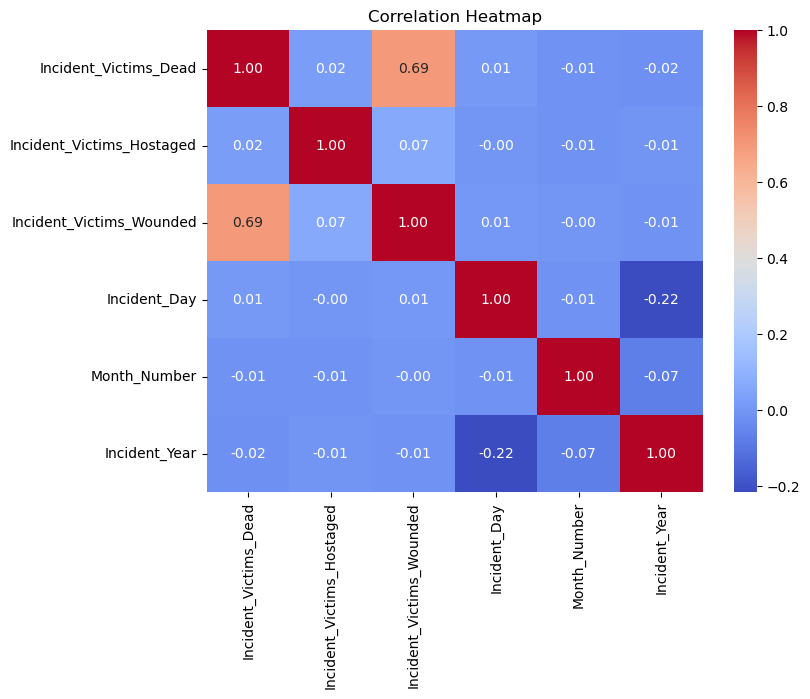

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [185]:
# df[df['Geocode_Anchor'].str.contains('Maguindanao') & df['Province_State'].isna()].shape

In [186]:
df_geocodeanchor_split = df['Geocode_Anchor'].str.split(',')
df_geocodeanchor_split.head(4)

0            [Herat,  Herat,  Afghanistan, ]
1                   [Lowgar,  Afghanistan, ]
2    [Baraki Barak,  Lowgar,  Afghanistan, ]
3       [Dwahmande,  Khowst,  Afghanistan, ]
Name: Geocode_Anchor, dtype: object

In [187]:
province_state_candidate = df_geocodeanchor_split.apply(lambda x:x[1])
print(province_state_candidate.shape)
province_state_candidate.head(4)

(8979,)


0           Herat
1     Afghanistan
2          Lowgar
3          Khowst
Name: Geocode_Anchor, dtype: object

In [188]:
print(type(province_state_candidate))
province_state_candidate.name = 'Province_State_Candidate'
province_state_candidate.shape

<class 'pandas.core.series.Series'>


(8979,)

In [189]:
df = pd.concat([df, province_state_candidate], axis=1)
df.head(5)

,ICN,Incident_Date,Date_Stamp,Subject,Country,ISO-3166-2,City,Geocode,Geocode_Anchor,Incident_Group_Type,Summary,Related_Term,Incident_Victims_Dead,...,Incident_Victims_Wounded,Incident_Included_Victims,Weapon,Event_Type,Geocode_Has_Value,Province_State,Assassination,IED,Incident_Day,Incident_Month,Month_Number,Incident_Year,Province_State_Candidate
0,201011951,1-Jul-10,2010-07-01,"1 bridge damaged in IED attack in Herat, Herat...",Afghanistan,AF,Herat,"34.363201,62.184971","Herat, Herat, Afghanistan,",Islamic Extremist (Sunni),"On 1 July 2010, in Herat, Herat, Afghanistan, ...","Afghanistan, bridge, Herat, July, targeting",0,...,0,No,"Explosive, IED",Bombing,Yes,Herat,No,Yes,1,Jul,7,2010,Herat
1,201014823,26-Sep-10,2010-09-26,"2 civilians killed in armed attack in Lowgar, ...",Afghanistan,AF,Lowgar,"34.019299,69.021111","Lowgar, Afghanistan,",Islamic Extremist (Sunni),"On 26 September 2010, in Lowgar, Afghanistan, ...","Afghanistan, Lowgar, September",2,...,0,Yes,Firearm,Armed Attack,Yes,Lowgar,No,No,26,Sep,9,2010,Afghanistan
2,201013905,10-Sep-10,2010-09-10,3 political party workers kidnapped in Baraki ...,Afghanistan,AF,Baraki Barak,"33.967499,68.948608","Baraki Barak, Lowgar, Afghanistan,",Islamic Extremist (Sunni),"On 10 September 2010, in Baraki Barak, Lowgar,...","Baraki Barak, candidate, Lowgar, parliamentary...",0,...,0,Yes,Firearm,Kidnapping,Yes,Lowgar,No,No,10,Sep,9,2010,Lowgar
3,201006361,14-Feb-10,2010-02-14,"2 police officers killed, 2 others wounded in ...",Afghanistan,AF,Dwahmande,"33.281666,69.584999","Dwahmande, Khowst, Afghanistan,",Islamic Extremist (Sunni),"On 14 February 2010, in Dwahmande, Khowst, Afg...","Dwahmande, February, Khowst, police, police ve...",2,...,2,Yes,"Explosive, IED",Bombing,Yes,Khowst,No,Yes,14,Feb,2,2010,Khowst
4,201012487,28-Jul-10,2010-07-28,"1 teacher killed in armed attack in Kaldar, Ba...",Afghanistan,AF,Kaldar,"37.166668,67.774170","Kaldar, Balkh, Afghanistan,",Islamic Extremist (Sunni),"Before 28 July 2010, in Kaldar, Balkh, Afghani...","Balkh, home, Kaldar, teacher",1,...,0,Yes,Firearm,Armed Attack,Yes,Balkh,No,No,28,Jul,7,2010,Balkh


In [190]:
pd.set_option('display.max_rows', None)
df[df['Province_State'].isnull()][['Geocode_Anchor','Province_State', 'Province_State_Candidate']]


,Geocode_Anchor,Province_State,Province_State_Candidate
6133,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6138,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6188,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6192,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6233,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6269,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6301,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
6331,"Cotabato, Maguindanao, Philippines,",NaN,Maguindanao
7410,"Gaza, Gaza Strip,",NaN,Gaza Strip
7411,"Gaza, Gaza Strip,",NaN,Gaza Strip


In [191]:
# axis=1
def fix_province_state(row):
    if row['Province_State'].isnull():
        if row['Province_State'] == 'West Bank':
            return row['Province_State_Candidate'] 
        elif row['Province_State'] == 'Maguindanao':
            return row['Province_State_Candidate'] 
        Maguindanao
    else:
        return row['Province_State']

In [200]:
df2['Province_State'].isnull().info()

<class 'pandas.core.series.Series'>
RangeIndex: 8979 entries, 0 to 8978
Series name: Province_State
Non-Null Count  Dtype
--------------  -----
8979 non-null   bool 
dtypes: bool(1)
memory usage: 8.9 KB


In [201]:
df2 = df.copy()
df2['Province_State'] = df2.apply(lambda row: fix_province_state(row), axis=1)
df2[df2['Province_State_Candidate'].isnull()]   # str.contains('West Bank')]

,ICN,Incident_Date,Date_Stamp,Subject,Country,ISO-3166-2,City,Geocode,Geocode_Anchor,Incident_Group_Type,Summary,Related_Term,Incident_Victims_Dead,...,Incident_Victims_Wounded,Incident_Included_Victims,Weapon,Event_Type,Geocode_Has_Value,Province_State,Assassination,IED,Incident_Day,Incident_Month,Month_Number,Incident_Year,Province_State_Candidate


In [194]:
import pandas as pd

# Create a sample DataFrame
data = {'ColumnA': [10, 25, 5, 40],
        'ColumnB': [2, 5, 1, 8]}
dfx = pd.DataFrame(data)

# Apply a lambda function to create a new column 'Result'
# based on conditions involving 'ColumnA' and 'ColumnB'
dfx['Result'] = dfx.apply(lambda row: 'High' if row['ColumnA'] > 20 and row['ColumnB'] > 4 else 'Low', axis=1)

print(dfx)

   ColumnA  ColumnB Result
0       10        2    Low
1       25        5   High
2        5        1    Low
3       40        8   High


In [ ]:
df.describe()

In [ ]:
df[['Incident_Victims_Dead', 'Incident_Victims_Hostaged', 'Incident_Victims_Wounded']].sum()

In [ ]:
df['Weapon'].value_counts().head(22)

In [ ]:
df['Event_Type'].value_counts().head(22)

In [ ]:
df['Weapon'].str.contains('Explosive')
# df['Weapon2'] = 

In [ ]:
df['Incident_Year'].value_counts()

In [ ]:
cols = ['Incident_Date', 'Date_Stamp', 'Subject', 'Country',
       'ISO-3166-2', 'City', 'Geocode', 'Geocode_Anchor',
       'Incident_Group_Type', 'Related_Term',
       'Incident_Victims_Dead', 'Incident_Victims_Hostaged',
       'Incident_Victims_Wounded', 'Incident_Included_Victims', 'Weapon',
       'Event_Type', 'Geocode_Has_Value', 'Province_State', 'Assassination',
       'IED', 'Incident_Year']
# for col in cols:
#     print(df[col].value_counts())

In [ ]:
df.describe()

In [ ]:
df.info()

In [ ]:
plt.style.use('fivethirtyeight')
df['Incident_Victims_Dead'].plot(kind='hist', bins=100, alpha=0.5, logy=True, xlabel='Deaths per Incident', ylabel='Number of Incidents (log scale)', figsize=(9,5))
ax = plt.gca()  # get current axis
formatter = mticker.FuncFormatter(lambda x, p: str(int(x)))  # convert scientific notation to integers
ax.set_title('Deaths Per Incident, December 2009-October 2010')
for container in ax.containers: # Iterate through bar containers
    ax.bar_label(container, fmt='%.0f', fontsize=8, label_type='edge', padding=1) # Use bar_label for easy annotation

ax.yaxis.set_major_formatter(formatter)
plt.savefig('visualizations/death_per_incident_pd.png')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# plt.style.use('fivethirtyeight')

In [ ]:
plt.style.use('fivethirtyeight')

sns.set(rc = {'figure.figsize':(9.0,12.5)})
ax = sns.countplot(df, y="Country", orient="v",  order = df['Country'].value_counts().index , alpha=.5)
ax.set_title('Number of Terrorist Incidents by Country, Dec. 2009-Oct. 2010')
ax.set_xlabel('Number of Terrorist Incidents')
for c in ax.containers:
    ax.bar_label(c, labels=[f'{x:,.0f}' for x in c.datavalues], fontsize=9, padding=0)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.tick_params(axis='both', labelsize=9) 
plt.style.use('fivethirtyeight')
plt.show()
# plt.savefig('visualizations/incidents_by_country_pd.png')
#print()

In [ ]:
# https://www.educative.io/answers/how-to-create-a-choropleth-map-with-plotly-express-in-python
import plotly.express as px
fig = px.choropleth(data_frame=df, 
                    locations='Country',
                    # locationmode='country names',
                    color='Country',
                    color_continuous_scale='color_scale',
                    projection='mercator')

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply the 'fivethirtyeight' style
plt.style.use('fivethirtyeight')

# Create some sample data
data = np.random.normal(size=100)

# Create a Seaborn plot
sns.histplot(data, kde=True)

# Add a title (optional)
plt.title("Histogram with FiveThirtyEight Style")

# Display the plot
plt.show()

In [ ]:
# sns.set(rc = {'figure.figsize':(9.0,12.5)})
 
# ax = sns.countplot(df, y="Country", orient="v",  order = df['Country'].value_counts().index)
ax = sns.countplot(df, y="Country", orient="v",  order = df['Country'].value_counts().iloc[:10].index)

# fig, ax = plt.subplots(figsize=(4, 5))
# ax.bar_label(ax.containers[0])
ax.set_title('Top Ten Countries by Terrorist Incidents, Dec. 2009-Oct. 2010')
ax.set_xlabel('Number of Terrorist Incidents')
for c in ax.containers:
    ax.bar_label(c, labels=[f'{x:,.0f}' for x in c.datavalues], fontsize=9, padding=2)


print()

In [ ]:
ax = sns.countplot(y=df['Country'],
                   order=df['Country'].value_counts(ascending=False).index);

abs_values = df['Country'].value_counts(ascending=False).values

ax.bar_label(container=ax.containers[0], labels=abs_values, fmt='{:,.0f}')
print()

In [ ]:
# Import necessary libraries
import plotly.express as px
import pandas as pd

# Load the data
df = px.data.gapminder()

# Display the first five rows of the data
print(df.head())

# Create a choropleth map using Plotly Express
fig = px.choropleth(df, 
                    locations="iso_alpha", 
                    color="gdpPercap", 
                    hover_name="country", 
                    animation_frame="year",
                    title="GDP per Capita by Country",
                    labels={"gdpPercap": "GDP per Capita"},
                    color_continuous_scale="Viridis")

# Display the map
fig.show()

In [ ]:
df